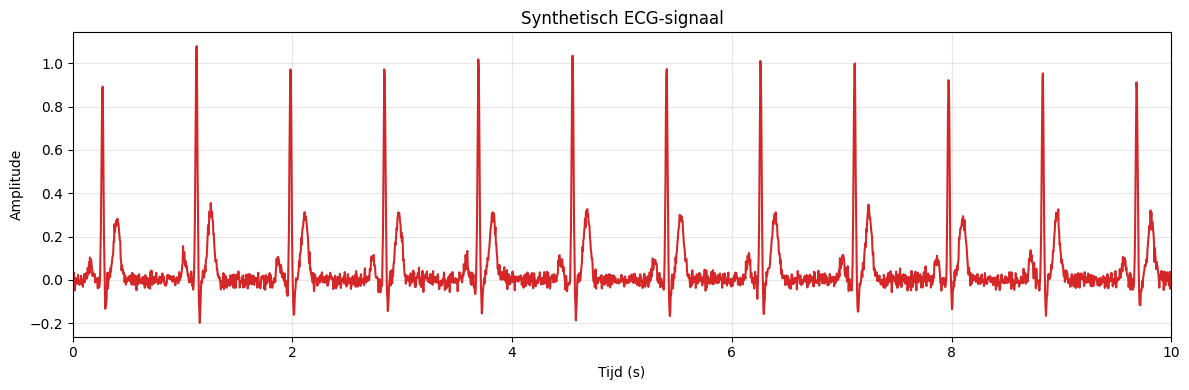

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 250  # samples per second
duration = 10  # seconds
heart_rate = 70  # beats per minute

# Tijdvector
num_samples = int(fs * duration)
t = np.linspace(0, duration, num_samples, endpoint=False)

# Basis-ECG-sjabloon voor één hartslag
beat_time = np.linspace(0, 1, fs, endpoint=False)

p_wave = 0.1 * np.exp(-((beat_time - 0.16) / 0.025) ** 2)
q_wave = -0.05 * np.exp(-((beat_time - 0.24) / 0.01) ** 2)
r_wave = 1.0 * np.exp(-((beat_time - 0.27) / 0.012) ** 2)
s_wave = -0.15 * np.exp(-((beat_time - 0.30) / 0.01) ** 2)
t_wave = 0.3 * np.exp(-((beat_time - 0.40) / 0.04) ** 2)

single_beat = p_wave + q_wave + r_wave + s_wave + t_wave

# Herhaal het sjabloon met een kleine variatie per beat
beat_interval = int(fs * 60 / heart_rate)
ecg = np.zeros(num_samples)
for i in range(0, num_samples, beat_interval):
    shift = np.random.randint(-3, 4)
    end = min(i + fs, num_samples)
    beat_length = end - i
    ecg[i:end] += single_beat[:beat_length] * (1 + 0.05 * np.random.randn())

# Voeg ruis toe
ecg += 0.02 * np.random.randn(num_samples)

# Plotten
plt.figure(figsize=(12, 4))
plt.plot(t, ecg, color="tab:red")
plt.title("Synthetisch ECG-signaal")
plt.xlabel("Tijd (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
